# Logistic Regression — From Scratch (Practice Notebook)

This notebook is my own version of a Logistic Regression practice lab. It covers the **same concepts** as the original
course exercise, but I've rebuilt every function from scratch and used **completely new datasets** so I actually
understand what each line of code is doing (not just copy-pasting a filled-in template).

Everything here runs top-to-bottom with **no external data files or helper modules** — it's fully self-contained,
so it's safe to upload straight to GitHub.

## What this notebook covers
- [1 - Setup](#1)
- [2 - Logistic Regression (linear decision boundary)](#2)
  - [2.1 Problem: Predicting whether a job applicant gets hired](#2.1)
  - [2.2 Loading & visualizing the data](#2.2)
  - [2.3 Sigmoid function](#2.3)
  - [2.4 Cost function](#2.4)
  - [2.5 Gradient](#2.5)
  - [2.6 Gradient descent](#2.6)
  - [2.7 Decision boundary plot](#2.7)
  - [2.8 Predictions & accuracy](#2.8)
- [3 - Regularized Logistic Regression (non-linear decision boundary)](#3)
  - [3.1 Problem: Predicting Pass/Fail of a manufactured part from two sensor readings](#3.1)
  - [3.2 Loading & visualizing the data](#3.2)
  - [3.3 Feature mapping (polynomial features)](#3.3)
  - [3.4 Regularized cost function](#3.4)
  - [3.5 Regularized gradient](#3.5)
  - [3.6 Gradient descent](#3.6)
  - [3.7 Decision boundary plot](#3.7)
  - [3.8 Predictions & accuracy](#3.8)
- [4 - Things to try next](#4)


<a name="1"></a>
## 1 - Setup

Only `numpy` and `matplotlib` are needed. No `utils.py`, no `.txt` data files — the datasets are generated
right here with `numpy`, so the notebook is fully reproducible on its own.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
np.set_printoptions(precision=4, suppress=True)

<a name="2"></a>
## 2 - Logistic Regression

<a name="2.1"></a>
### 2.1 Problem Statement

Suppose I'm building a simple model for an HR team. For every past applicant we know:
- `x1`: **years of relevant work experience**
- `x2`: **aptitude test score (0-100)**
- `y`: whether the applicant was **hired (1)** or **not hired (0)**

The goal is to build a logistic regression classifier that predicts the probability a *new* applicant gets hired,
based on their experience and test score — the same kind of binary classification problem as the original exam-scores
exercise, just a different real-world story.

<a name="2.2"></a>
### 2.2 Loading and visualizing the data

Since there's no dataset file to download, I generate a synthetic-but-realistic dataset myself:
- `experience` is drawn uniformly between 0 and 10 years
- `test_score` is drawn uniformly between 40 and 100
- the **true** hiring decision follows a linear rule (`1.4*experience + 0.9*test_score - 95 > 0`), and then I
  add random noise so the data isn't perfectly separable — just like real data never is.

In [2]:
def load_hiring_data(m=100, seed=42):
    '''Generate a synthetic hiring dataset with a roughly-linear decision boundary.'''
    rng = np.random.default_rng(seed)

    experience = rng.uniform(0, 10, m)          # years of experience
    test_score = rng.uniform(40, 100, m)        # aptitude test score

    # underlying "true" signal that drives the hiring decision
    signal = 1.4 * experience + 0.9 * test_score - 95

    # add noise so classes overlap a bit (real-world data is never perfectly separable)
    noise = rng.normal(0, 6, m)
    y = (signal + noise > 0).astype(float)

    X = np.column_stack((experience, test_score))
    return X, y

X_train, y_train = load_hiring_data()

In [3]:
print("First five elements in X_train are:\n", X_train[:5])
print("Type of X_train:", type(X_train))

First five elements in X_train are:
 [[ 7.7396 94.5148]
 [ 4.3888 81.9824]
 [ 8.586  55.9522]
 [ 6.9737 98.1506]
 [ 0.9418 86.7251]]
Type of X_train: <class 'numpy.ndarray'>


In [4]:
print("First five elements in y_train are:\n", y_train[:5])
print("Type of y_train:", type(y_train))

First five elements in y_train are:
 [1. 0. 0. 1. 0.]
Type of y_train: <class 'numpy.ndarray'>


In [5]:
print('The shape of X_train is: ' + str(X_train.shape))
print('The shape of y_train is: ' + str(y_train.shape))
print('We have m = %d training examples' % (len(y_train)))

The shape of X_train is: (100, 2)
The shape of y_train is: (100,)
We have m = 100 training examples


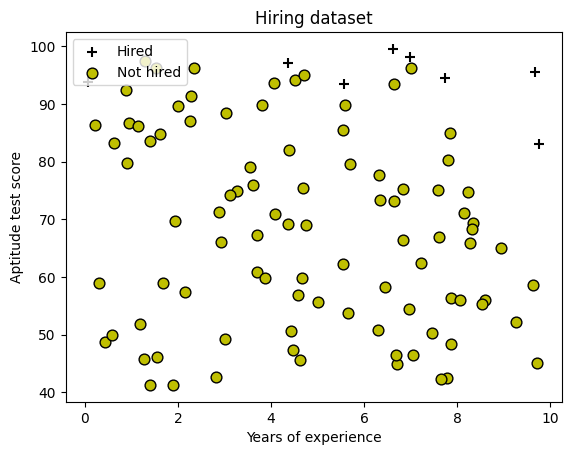

In [6]:
def plot_data(X, y, pos_label="y=1", neg_label="y=0"):
    '''Scatter-plot a 2-feature binary classification dataset.'''
    positive = y == 1
    negative = y == 0

    plt.scatter(X[positive, 0], X[positive, 1], marker='+', c='k', s=60, label=pos_label)
    plt.scatter(X[negative, 0], X[negative, 1], marker='o', facecolors='y',
                edgecolors='k', s=60, label=neg_label)

plot_data(X_train, y_train, pos_label="Hired", neg_label="Not hired")
plt.ylabel('Aptitude test score')
plt.xlabel('Years of experience')
plt.legend(loc="upper left")
plt.title("Hiring dataset")
plt.show()

<a name="2.3"></a>
### 2.3 Sigmoid function

The logistic regression model is

$$ f_{\mathbf{w},b}(x) = g(\mathbf{w}\cdot \mathbf{x} + b)$$

where $g$ is the **sigmoid function**:

$$g(z) = \frac{1}{1+e^{-z}}$$

`z` can be a single number or a whole array — the sigmoid should work element-wise either way.

In [7]:
def sigmoid(z):
    '''
    Compute the sigmoid of z

    Args:
        z (scalar or ndarray): A scalar or numpy array of any size.

    Returns:
        g (scalar or ndarray): sigmoid(z), with the same shape as z if z is a numpy array.
    '''
    z = np.clip(z, -500, 500)   # avoid overflow warnings for very large |z|
    g = 1 / (1 + np.exp(-z))
    return g

In [8]:
# Quick sanity checks
value = 0
print(f"sigmoid({value}) = {sigmoid(value)}")               # expect 0.5

print("sigmoid([-1, 0, 1, 2]) =", sigmoid(np.array([-1, 0, 1, 2])))
# expect [0.2689 0.5    0.7311 0.8808]

sigmoid(0) = 0.5
sigmoid([-1, 0, 1, 2]) = [0.2689 0.5    0.7311 0.8808]


<a name="2.4"></a>
### 2.4 Cost function for logistic regression

$$ J(\mathbf{w},b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \right] $$

where $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w}\cdot\mathbf{x}^{(i)} + b)$ and $g$ is the sigmoid function above.

In [9]:
def compute_cost(X, y, w, b, lambda_=0):
    '''
    Computes the (unregularized) logistic regression cost over all examples.

    Args:
      X : (ndarray Shape (m,n)) data, m examples by n features
      y : (ndarray Shape (m,))  target values
      w : (ndarray Shape (n,))  model weights
      b : (scalar)              model bias
      lambda_ : unused here, kept for a consistent signature with the regularized version

    Returns:
      total_cost : (scalar) cost
    '''
    m, n = X.shape

    z = X @ w + b
    f_wb = sigmoid(z)

    eps = 1e-15  # avoid log(0)
    f_wb = np.clip(f_wb, eps, 1 - eps)

    loss = -y * np.log(f_wb) - (1 - y) * np.log(1 - f_wb)
    total_cost = np.sum(loss) / m
    return total_cost

In [10]:
m, n = X_train.shape

# Cost with w, b initialized to zero
initial_w = np.zeros(n)
initial_b = 0.
cost = compute_cost(X_train, y_train, initial_w, initial_b)
print('Cost at initial w and b (zeros): {:.3f}'.format(cost))
# With zeros for w and b, sigmoid(0)=0.5 everywhere, so this should print 0.693 (i.e. -ln(0.5))

Cost at initial w and b (zeros): 0.693


In [11]:
# Cost with some arbitrary non-zero w, b
test_w = np.array([0.05, 0.01])
test_b = -3.0
cost = compute_cost(X_train, y_train, test_w, test_b)
print('Cost at test w and b (non-zeros): {:.3f}'.format(cost))

Cost at test w and b (non-zeros): 0.262


<a name="2.5"></a>
### 2.5 Gradient for logistic regression

$$
\frac{\partial J(\mathbf{w},b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})
$$
$$
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})\,x_{j}^{(i)}
$$

In [12]:
def compute_gradient(X, y, w, b, lambda_=0):
    '''
    Computes the gradient for logistic regression (unregularized).

    Args:
      X : (ndarray Shape (m,n)) data, m examples by n features
      y : (ndarray Shape (m,))  target values
      w : (ndarray Shape (n,))  model weights
      b : (scalar)              model bias
      lambda_ : unused here, kept for a consistent signature with the regularized version

    Returns:
      dj_db : (scalar)             gradient of the cost w.r.t. b
      dj_dw : (ndarray Shape (n,)) gradient of the cost w.r.t. w
    '''
    m, n = X.shape

    z = X @ w + b
    f_wb = sigmoid(z)
    err = f_wb - y                 # shape (m,)

    dj_dw = (X.T @ err) / m        # shape (n,)
    dj_db = np.sum(err) / m        # scalar

    return dj_db, dj_dw

In [13]:
initial_w = np.zeros(n)
initial_b = 0.

dj_db, dj_dw = compute_gradient(X_train, y_train, initial_w, initial_b)
print(f'dj_db at initial w and b (zeros): {dj_db}')
print(f'dj_dw at initial w and b (zeros): {dj_dw.tolist()}')

dj_db at initial w and b (zeros): 0.42
dj_dw at initial w and b (zeros): [1.92584384255516, 27.478891288517254]


In [14]:
test_w = np.array([0.05, -0.02])
test_b = -2.0
dj_db, dj_dw = compute_gradient(X_train, y_train, test_w, test_b)

print('dj_db at test w and b:', dj_db)
print('dj_dw at test w and b:', dj_dw.tolist())

dj_db at test w and b: -0.036462683346261675
dj_dw at test w and b: [-0.2758404073123522, -4.756515934507114]


<a name="2.6"></a>
### 2.6 Learning parameters using gradient descent

Standard batch gradient descent — repeatedly nudge `w` and `b` in the direction that reduces the cost, using the
gradient function above.

In [15]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function,
                      alpha, num_iters, lambda_=0, print_every=1000):
    '''
    Performs batch gradient descent to learn w, b.

    Args:
      X, y                        : training data
      w_in, b_in                  : initial parameters
      cost_function                : function to compute cost
      gradient_function            : function to compute gradient
      alpha : (float)              learning rate
      num_iters : (int)            number of iterations
      lambda_ : (float)            regularization constant
      print_every : (int)          how often to log progress

    Returns:
      w, b          : learned parameters
      J_history     : cost at every iteration (for plotting/debugging)
    '''
    m = len(X)
    J_history = []

    w = copy_w = w_in.copy()
    b = b_in

    for i in range(num_iters):
        dj_db, dj_dw = gradient_function(X, y, w, b, lambda_)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        if i < 100000:  # guard against a huge history on very long runs
            J_history.append(cost_function(X, y, w, b, lambda_))

        if i % print_every == 0 or i == num_iters - 1:
            print(f"Iteration {i:5d}: Cost {J_history[-1]:8.3f}")

    return w, b, J_history

In [16]:
np.random.seed(1)
initial_w = 0.01 * (np.random.rand(2) - 0.5)
initial_b = -8.

iterations = 10000
alpha = 0.001

w, b, J_history = gradient_descent(X_train, y_train, initial_w, initial_b,
                                    compute_cost, compute_gradient,
                                    alpha, iterations)

Iteration     0: Cost    0.567
Iteration  1000: Cost    0.182
Iteration  2000: Cost    0.180
Iteration  3000: Cost    0.179
Iteration  4000: Cost    0.179


Iteration  5000: Cost    0.179

Iteration  6000: Cost    0.179


Iteration  7000: Cost    0.179
Iteration  8000: Cost    0.179
Iteration  9000: Cost    0.178
Iteration  9999: Cost    0.178


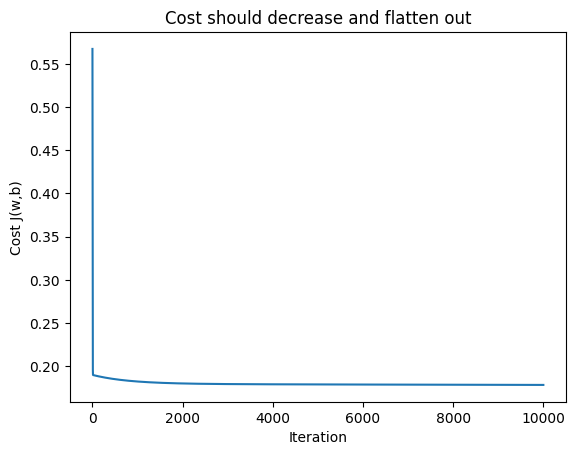

In [17]:
plt.plot(J_history)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Cost should decrease and flatten out")
plt.show()

<a name="2.7"></a>
### 2.7 Plotting the decision boundary

For a linear model, the decision boundary is the line where $\mathbf{w}\cdot\mathbf{x}+b = 0$.

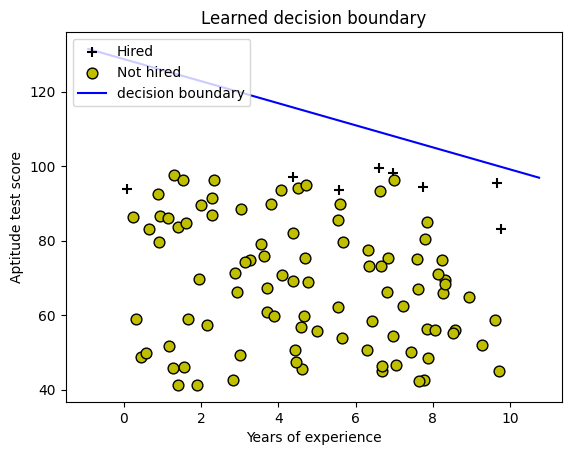

In [18]:
def plot_decision_boundary_linear(w, b, X, y, pos_label="y=1", neg_label="y=0",
                                   xlabel="x1", ylabel="x2"):
    plot_data(X, y, pos_label=pos_label, neg_label=neg_label)

    x1 = np.array([np.min(X[:, 0]) - 1, np.max(X[:, 0]) + 1])
    # w0*x1 + w1*x2 + b = 0  ->  x2 = -(w0*x1 + b) / w1
    x2 = -(w[0] * x1 + b) / w[1]

    plt.plot(x1, x2, c="b", label="decision boundary")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(loc="upper left")

plot_decision_boundary_linear(w, b, X_train, y_train,
                               pos_label="Hired", neg_label="Not hired",
                               xlabel="Years of experience", ylabel="Aptitude test score")
plt.title("Learned decision boundary")
plt.show()

<a name="2.8"></a>
### 2.8 Evaluating logistic regression

Turn the model's probability output into a hard 0/1 prediction using a 0.5 threshold, then measure training accuracy.

In [19]:
def predict(X, w, b):
    '''
    Predict 0/1 labels using learned logistic regression parameters w, b.

    Args:
      X : (ndarray Shape (m,n)) data, m examples by n features
      w : (ndarray Shape (n,))  model weights
      b : (scalar)              model bias

    Returns:
      p : (ndarray (m,)) predictions (0 or 1), threshold at 0.5
    '''
    f_wb = sigmoid(X @ w + b)
    p = (f_wb >= 0.5).astype(float)
    return p

In [20]:
# Quick smoke test on a few made-up points
tmp_X = np.array([[0.5, 45], [8.0, 90], [3.0, 60], [9.5, 95]])
tmp_w = np.array([0.15, 0.05])
tmp_b = -6.0
print("Sample predictions:", predict(tmp_X, tmp_w, tmp_b))

Sample predictions: [0. 0. 0. 1.]


In [21]:
p = predict(X_train, w, b)
print('Train Accuracy: %f' % (np.mean(p == y_train) * 100))

Train Accuracy: 92.000000


<a name="3"></a>
## 3 - Regularized Logistic Regression

<a name="3.1"></a>
### 3.1 Problem Statement

Now a harder problem: a factory runs two automated sensor tests (`sensor1`, `sensor2`, both roughly in the range
-1 to 1) on manufactured parts, and each part is marked **Pass (1)** or **Fail (0)**. The good parts cluster in a
roughly circular region of the sensor readings — a **plain straight-line boundary won't work here**, just like the
microchip QA example. This is the perfect setting to use **polynomial feature mapping + regularization**.

<a name="3.2"></a>
### 3.2 Loading and visualizing the data

Again, generated synthetically: points inside a certain radius (with noise) are "Pass", points outside are "Fail".

In [22]:
def load_sensor_data(m=120, seed=7):
    '''Generate a synthetic QA dataset with a circular (non-linear) decision region.'''
    rng = np.random.default_rng(seed)

    theta = rng.uniform(0, 2 * np.pi, m)
    radius = rng.uniform(0, 1.3, m)

    x1 = radius * np.cos(theta) + rng.normal(0, 0.08, m)
    x2 = radius * np.sin(theta) + rng.normal(0, 0.08, m)

    # "good" parts fall inside radius 0.65 of the origin (with a bit of label noise)
    true_pass = (radius < 0.65).astype(float)
    flip = rng.random(m) < 0.05
    y = np.where(flip, 1 - true_pass, true_pass)

    X = np.column_stack((x1, x2))
    return X, y

X_train, y_train = load_sensor_data()

In [23]:
print("X_train:", X_train[:5])
print("Type of X_train:", type(X_train))
print("y_train:", y_train[:5])
print("Type of y_train:", type(y_train))

X_train: [[-0.0203 -0.0163]
 [ 0.6513 -0.4752]
 [ 0.0497 -1.0243]
 [ 0.0667  0.6991]
 [-0.2331  1.0468]]
Type of X_train: <class 'numpy.ndarray'>
y_train: [1. 0. 0. 0. 0.]
Type of y_train: <class 'numpy.ndarray'>


In [24]:
print('The shape of X_train is: ' + str(X_train.shape))
print('The shape of y_train is: ' + str(y_train.shape))
print('We have m = %d training examples' % (len(y_train)))

The shape of X_train is: (120, 2)
The shape of y_train is: (120,)
We have m = 120 training examples


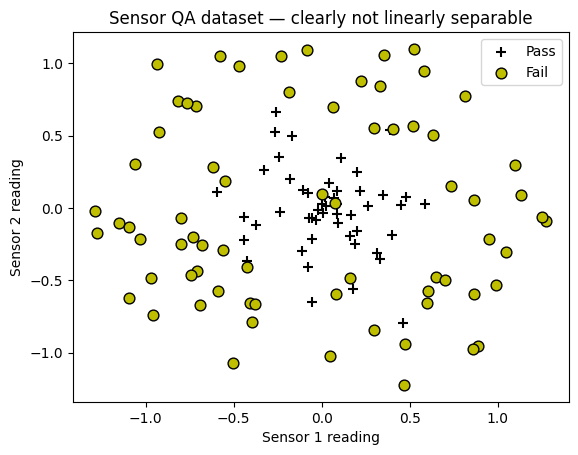

In [25]:
plot_data(X_train, y_train, pos_label="Pass", neg_label="Fail")
plt.ylabel('Sensor 2 reading')
plt.xlabel('Sensor 1 reading')
plt.legend(loc="upper right")
plt.title("Sensor QA dataset — clearly not linearly separable")
plt.show()

<a name="3.3"></a>
### 3.3 Feature mapping

To fit this non-linear region, I expand the 2 raw features into all polynomial combinations up to degree 6:

$$\mathrm{map\_feature}(x) =
\left[\begin{array}{c}
x_1\\ x_2\\ x_1^2\\ x_1 x_2\\ x_2^2\\ x_1^3\\ \vdots\\ x_1 x_2^5\\ x_2^6\end{array}\right]$$

This turns 2 features into a 27-dimensional feature vector, letting a "linear" classifier in this new space trace
out a curved boundary in the original 2D space.

In [26]:
def map_feature(X1, X2, degree=6):
    '''
    Maps two features to all polynomial terms of X1 and X2 up to the given degree.

    Args:
      X1, X2 : (ndarray Shape (m,)) the two raw features
      degree : (int) highest total polynomial degree to include

    Returns:
      out : (ndarray Shape (m, n_features)) the mapped feature matrix
    '''
    X1 = np.atleast_1d(X1)
    X2 = np.atleast_1d(X2)

    out = []
    for i in range(1, degree + 1):
        for j in range(i + 1):
            out.append((X1 ** (i - j)) * (X2 ** j))

    return np.stack(out, axis=1)

In [27]:
print("Original shape of data:", X_train.shape)

X_mapped = map_feature(X_train[:, 0], X_train[:, 1])
print("Shape after feature mapping:", X_mapped.shape)

Original shape of data: (120, 2)
Shape after feature mapping: (120, 27)


In [28]:
print("X_train[0]:", X_train[0])
print("mapped X_train[0]:", X_mapped[0])

X_train[0]: [-0.0203 -0.0163]
mapped X_train[0]: [-0.0203 -0.0163  0.0004  0.0003  0.0003 -0.     -0.     -0.     -0.
  0.      0.      0.      0.      0.     -0.     -0.     -0.     -0.
 -0.     -0.      0.      0.      0.      0.      0.      0.      0.    ]


<a name="3.4"></a>
### 3.4 Cost function for regularized logistic regression

$$J(\mathbf{w},b) = \frac{1}{m}  \sum_{i=0}^{m-1} \left[ -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \right] + \frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$$

Same as before, plus an L2 penalty on the weights (note: `b` is **not** regularized).

In [29]:
def compute_cost_reg(X, y, w, b, lambda_=1):
    '''
    Computes the regularized logistic regression cost.

    Args:
      X : (ndarray Shape (m,n)) data, m examples by n features
      y : (ndarray Shape (m,))  target values
      w : (ndarray Shape (n,))  model weights
      b : (scalar)              model bias
      lambda_ : (scalar) regularization strength

    Returns:
      total_cost : (scalar) cost
    '''
    m, n = X.shape

    cost_without_reg = compute_cost(X, y, w, b)

    reg_cost = np.sum(w ** 2)
    reg_cost = (lambda_ / (2 * m)) * reg_cost

    total_cost = cost_without_reg + reg_cost
    return total_cost

In [30]:
np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1]) - 0.5
initial_b = 0.5
lambda_ = 0.5
cost = compute_cost_reg(X_mapped, y_train, initial_w, initial_b, lambda_)

print("Regularized cost:", cost)

Regularized cost: 0.7797901721852215


<a name="3.5"></a>
### 3.5 Gradient for regularized logistic regression

$$\frac{\partial J(\mathbf{w},b)}{\partial b} = \frac{1}{m}  \sum_{i=0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})$$

$$\frac{\partial J(\mathbf{w},b)}{\partial w_j} = \left( \frac{1}{m}  \sum_{i=0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) x_j^{(i)} \right) + \frac{\lambda}{m} w_j$$

In [31]:
def compute_gradient_reg(X, y, w, b, lambda_=1):
    '''
    Computes the gradient for regularized logistic regression.

    Args:
      X : (ndarray Shape (m,n)) data, m examples by n features
      y : (ndarray Shape (m,))  target values
      w : (ndarray Shape (n,))  model weights
      b : (scalar)              model bias
      lambda_ : (scalar) regularization strength

    Returns:
      dj_db : (scalar)             gradient of the cost w.r.t. b
      dj_dw : (ndarray Shape (n,)) gradient of the cost w.r.t. w
    '''
    m, n = X.shape

    dj_db, dj_dw = compute_gradient(X, y, w, b)

    dj_dw = dj_dw + (lambda_ / m) * w   # b is intentionally left unregularized

    return dj_db, dj_dw

In [32]:
np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1]) - 0.5
initial_b = 0.5
lambda_ = 0.5

dj_db, dj_dw = compute_gradient_reg(X_mapped, y_train, initial_w, initial_b, lambda_)

print(f"dj_db: {dj_db}")
print(f"First few elements of regularized dj_dw:\n {dj_dw[:4].tolist()}")

dj_db: 0.16607993357074025
First few elements of regularized dj_dw:
 [-0.09542261612962473, -0.006838308357446321, 0.1716312858985453, 0.004468901866924996]


<a name="3.6"></a>
### 3.6 Learning parameters using gradient descent

Reusing the exact same `gradient_descent` function from Part 2 — just pointing it at the regularized cost/gradient
functions and the mapped features.

In [33]:
np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1]) - 0.5
initial_b = 1.

lambda_ = 0.01
iterations = 10000
alpha = 0.5

w, b, J_history = gradient_descent(X_mapped, y_train, initial_w, initial_b,
                                    compute_cost_reg, compute_gradient_reg,
                                    alpha, iterations, lambda_)

Iteration     0: Cost    0.752


Iteration  1000: Cost    0.226


Iteration  2000: Cost    0.218
Iteration  3000: Cost    0.216
Iteration  4000: Cost    0.215


Iteration  5000: Cost    0.214


Iteration  6000: Cost    0.213


Iteration  7000: Cost    0.213


Iteration  8000: Cost    0.212
Iteration  9000: Cost    0.212
Iteration  9999: Cost    0.211


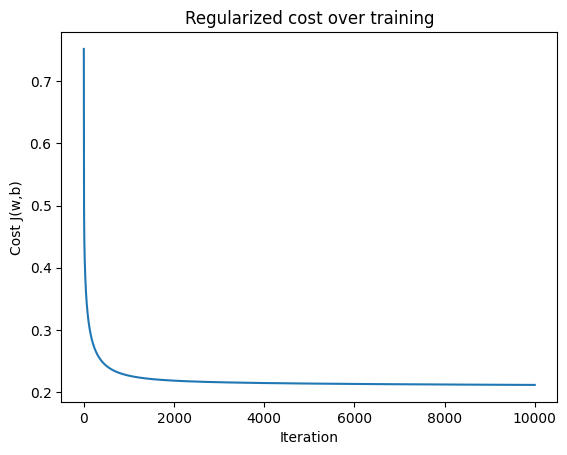

In [34]:
plt.plot(J_history)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w,b)")
plt.title("Regularized cost over training")
plt.show()

<a name="3.7"></a>
### 3.7 Plotting the decision boundary

Because the boundary is non-linear now, I can't draw a straight line — instead I evaluate the model on a fine grid
covering the plot and draw a contour where the predicted probability crosses 0.5.

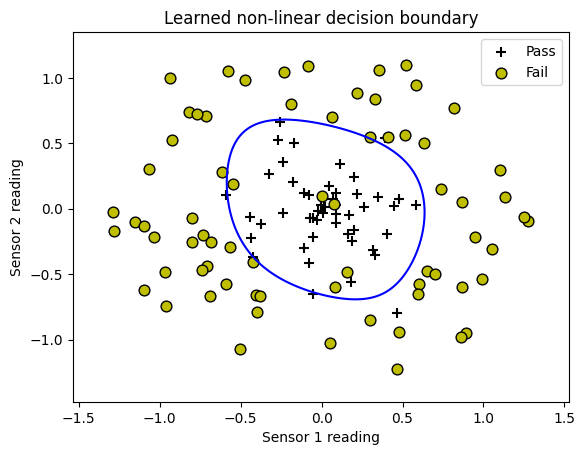

In [35]:
def plot_decision_boundary_nonlinear(w, b, X, y, pos_label="y=1", neg_label="y=0",
                                      xlabel="x1", ylabel="x2", degree=6):
    plot_data(X, y, pos_label=pos_label, neg_label=neg_label)

    u = np.linspace(X[:, 0].min() - 0.25, X[:, 0].max() + 0.25, 200)
    v = np.linspace(X[:, 1].min() - 0.25, X[:, 1].max() + 0.25, 200)

    z = np.zeros((len(u), len(v)))
    for i in range(len(u)):
        mapped = map_feature(np.array([u[i]] * len(v)), v, degree=degree)
        z[i, :] = sigmoid(mapped @ w + b)
    z = z.T

    plt.contour(u, v, z, levels=[0.5], colors="b")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(loc="upper right")

plot_decision_boundary_nonlinear(w, b, X_train, y_train,
                                  pos_label="Pass", neg_label="Fail",
                                  xlabel="Sensor 1 reading", ylabel="Sensor 2 reading")
plt.title("Learned non-linear decision boundary")
plt.show()

<a name="3.8"></a>
### 3.8 Evaluating the regularized model

In [36]:
p = predict(X_mapped, w, b)
print('Train Accuracy: %f' % (np.mean(p == y_train) * 100))

Train Accuracy: 91.666667


<a name="4"></a>
## 4 - Things to try next

A few small experiments that build intuition, without needing any new code:

- **Change `lambda_`** in Part 3 to something large (e.g. `10`) and re-run — the boundary should get smoother /
  simpler and training accuracy should drop a bit (that's the regularization trade-off).
- **Change `lambda_` to `0`** and re-run — watch the boundary get more "wiggly" as it starts overfitting the noisy points.
- **Change the noise level** in `load_hiring_data` / `load_sensor_data` (the `rng.normal(...)` and `flip` lines) and
  see how it affects the final training accuracy.
- **Change `alpha` or `iterations`** in either gradient descent call and watch how the cost curve changes — too high
  an `alpha` can make the cost jump around instead of smoothly decreasing.

This notebook intentionally mirrors the structure of the classic exam-scores / microchip-QA logistic regression lab,
but with the math implemented and explained in my own words, on my own datasets.
